In [1]:
import os

# Veri setinin ana dizini
base_path = '/kaggle/input/intel-image-classification'

# Klasörleri listeleyelim
for dirname, _, filenames in os.walk(base_path):
    # Çok fazla dosya ismi basmasın diye sadece klasör isimlerine bakalım
    if len(filenames) > 0:
        print(f"Klasör: {dirname} | Dosya Sayısı: {len(filenames)}")

Klasör: /kaggle/input/intel-image-classification/seg_train/seg_train/mountain | Dosya Sayısı: 2512
Klasör: /kaggle/input/intel-image-classification/seg_train/seg_train/street | Dosya Sayısı: 2382
Klasör: /kaggle/input/intel-image-classification/seg_train/seg_train/buildings | Dosya Sayısı: 2191
Klasör: /kaggle/input/intel-image-classification/seg_train/seg_train/sea | Dosya Sayısı: 2274
Klasör: /kaggle/input/intel-image-classification/seg_train/seg_train/forest | Dosya Sayısı: 2271
Klasör: /kaggle/input/intel-image-classification/seg_train/seg_train/glacier | Dosya Sayısı: 2404
Klasör: /kaggle/input/intel-image-classification/seg_pred/seg_pred | Dosya Sayısı: 7301
Klasör: /kaggle/input/intel-image-classification/seg_test/seg_test/mountain | Dosya Sayısı: 525
Klasör: /kaggle/input/intel-image-classification/seg_test/seg_test/street | Dosya Sayısı: 501
Klasör: /kaggle/input/intel-image-classification/seg_test/seg_test/buildings | Dosya Sayısı: 437
Klasör: /kaggle/input/intel-image-classi

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Yeni Uzmanlarımız
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

2026-02-10 16:13:30.112770: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770740010.345271      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770740010.409547      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770740010.955338      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770740010.955379      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770740010.955382      23 computation_placer.cc:177] computation placer alr

In [3]:
# 1. Musluk (Generator) Ayarları
# validation_split=0.2 diyerek %20'yi test için ayıracağımızı baştan söylüyoruz.
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2) 

# 2. Eğitim Musluğunu Açıyoruz (Training)
train_generator = datagen.flow_from_directory(
    '/kaggle/input/intel-image-classification/seg_train/seg_train',
    target_size=(224, 224), # ResNet'in beklediği standart boyut
    batch_size=32,          # Her seferinde 32 resim oku (RAM dostu)
    class_mode='categorical',
    subset='training'       # %80'lik kısmı buraya al
)

# 3. Doğrulama Musluğunu Açıyoruz (Validation)
val_generator = datagen.flow_from_directory(
    '/kaggle/input/intel-image-classification/seg_train/seg_train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'      # %20'lik kısmı buraya al
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


In [4]:
from tensorflow.keras.applications import ResNet50

# include_top=False diyerek ImageNet'in 1000 sınıflık son katmanını siliyoruz.
# weights='imagenet' diyerek 14 milyon resimle eğitilmiş tecrübeyi içeri alıyoruz.
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# Usta ressamın ellerini (CNN katmanlarını) sabitliyoruz, değişmesinler.
base_model.trainable = True


I0000 00:00:1770740028.173164      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770740028.189574      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,                     # 1. Hazır gövde (CNN kısmı)
    layers.GlobalAveragePooling2D(),# 2. 3B veriyi 1B vektöre indir (Flatten yerine)
    layers.Dense(256, activation='relu'), # 3. Senin gizli katmanların (ANN)
    layers.Dropout(0.5),            # 4. Ezberlemeyi önleyici kalkan
    layers.Dense(6, activation='softmax') # 5. Sonuç: 6 Sınıf ve Olasılıklar
])

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 24,060,678 (91.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [7]:
# Modeli tekrar derliyoruz (re-compile)
# Öğrenme hızını standart 0.001'den 0.00001'e (100 kat daha yavaş) çekiyoruz.
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
# Eğitimi başlatıyoruz
history = model.fit(
    train_generator,
    epochs=7,                      # Veri seti üzerinden kaç tur geçilecek
    validation_data=val_generator,  # Her tur sonunda yapılacak sınav
    verbose=1                       # Eğitim sürecini canlı izlemek için
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/7


I0000 00:00:1770740061.558991      80 service.cc:152] XLA service 0x7a58cc002780 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770740061.559028      80 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770740061.559031      80 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770740067.091564      80 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-10 16:14:40.169224: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv %cudnn-conv-bw-input.41 = (f32[32,64,56,56]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,56,56]{3,2,1,0} %bitcast.62740, f32[64,64,3,3]{3,2,1,0} %bitcast.50532), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", metadata={op_type="Conv2DBackpropInput" op_name="gradient_tape/sequential_1/resnet50_1/conv2_block3_2_conv_1/convolution/Con

351/351 ━━━━━━━━━━━━━━━━━━━━ 255s 543ms/step - accuracy: 0.5147 - loss: 1.3321 - val_accuracy: 0.2518 - val_loss: 2.0484
Epoch 2/7
351/351 ━━━━━━━━━━━━━━━━━━━━ 136s 386ms/step - accuracy: 0.8804 - loss: 0.3552 - val_accuracy: 0.7821 - val_loss: 0.5587
Epoch 3/7
351/351 ━━━━━━━━━━━━━━━━━━━━ 137s 391ms/step - accuracy: 0.9273 - loss: 0.2299 - val_accuracy: 0.9155 - val_loss: 0.2486
Epoch 4/7
351/351 ━━━━━━━━━━━━━━━━━━━━ 130s 370ms/step - accuracy: 0.9397 - loss: 0.1728 - val_accuracy: 0.9223 - val_loss: 0.2118
Epoch 5/7
351/351 ━━━━━━━━━━━━━━━━━━━━ 135s 385ms/step - accuracy: 0.9613 - loss: 0.1160 - val_accuracy: 0.9251 - val_loss: 0.2230
Epoch 6/7
351/351 ━━━━━━━━━━━━━━━━━━━━ 141s 403ms/step - accuracy: 0.9727 - loss: 0.0800 - val_accuracy: 0.9297 - val_loss: 0.2353
Epoch 7/7
351/351 ━━━━━━━━━━━━━━━━━━━━ 143s 406ms/step - accuracy: 0.9868 - loss: 0.0489 - val_accuracy: 0.9322 - val_loss: 0.2399


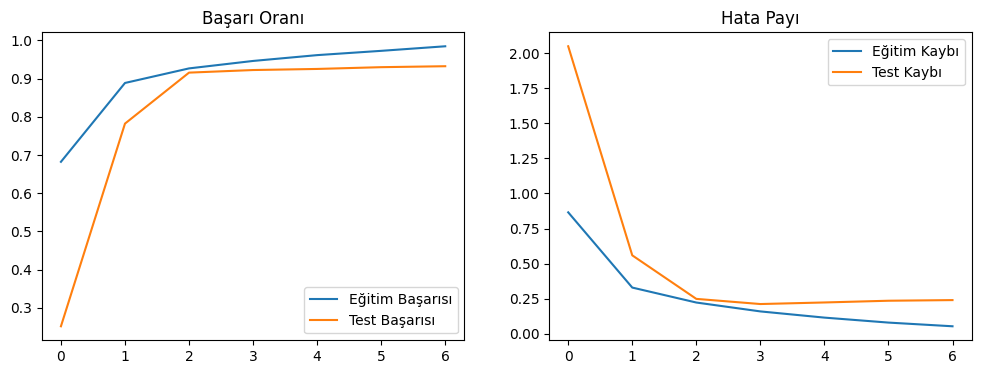

In [9]:
# Başarı ve Kayıp Grafikleri
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Başarısı')
plt.plot(history.history['val_accuracy'], label='Test Başarısı')
plt.title('Başarı Oranı')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Test Kaybı')
plt.title('Hata Payı')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


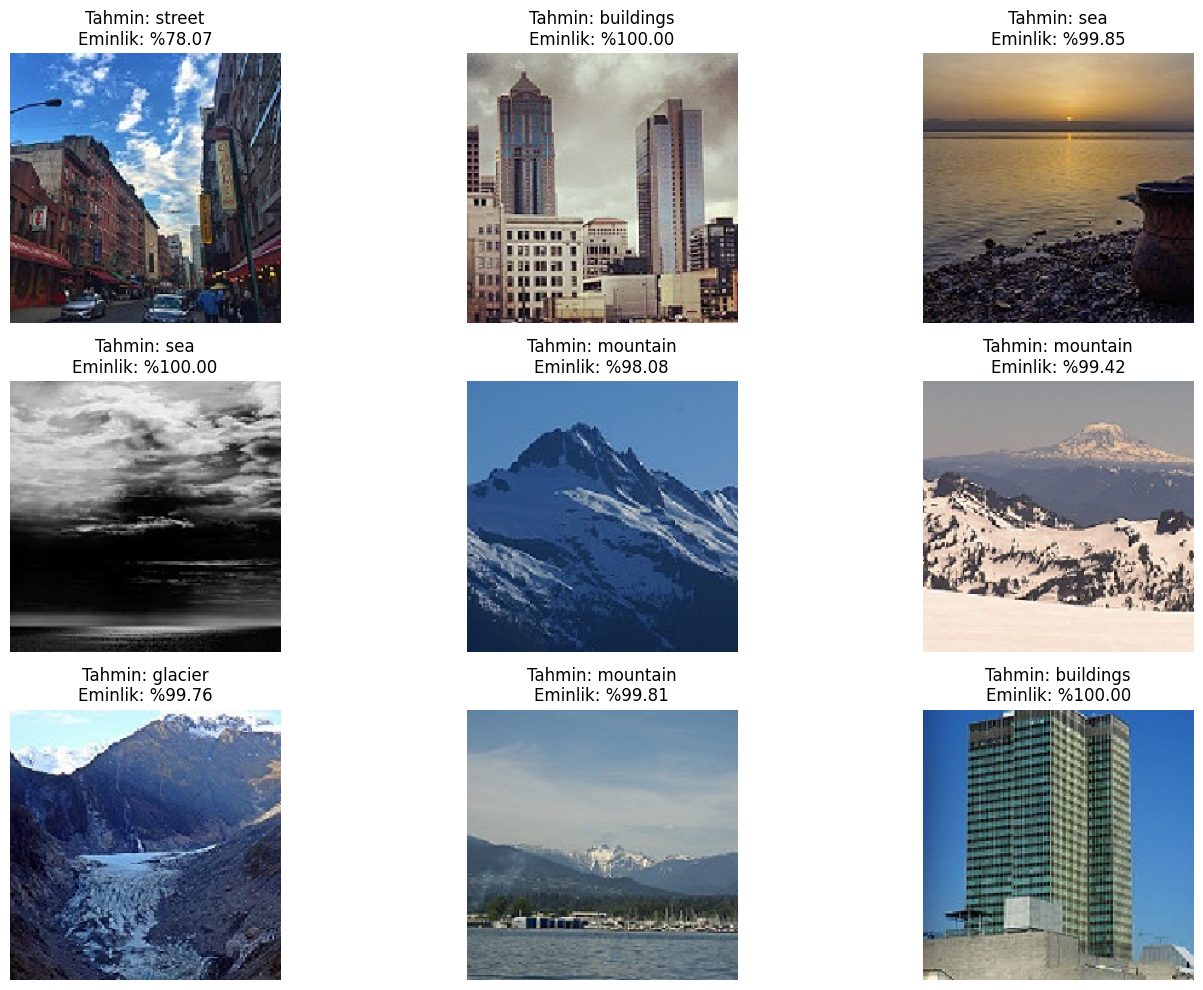

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.preprocessing import image

# Tahmin yapılacak klasör yolu
pred_path = '/kaggle/input/intel-image-classification/seg_pred/seg_pred'
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

plt.figure(figsize=(15, 10))

# Rastgele 9 resim seçip gösterelim
files = os.listdir(pred_path)
for i in range(9):
    random_file = np.random.choice(files)
    img_path = os.path.join(pred_path, random_file)
    
    # Resmi yükle ve modele hazırla
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)
    
    # Tahmin yap
    pred = model.predict(img_batch)
    predicted_class = class_names[np.argmax(pred)]
    confidence = np.max(pred)
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Tahmin: {predicted_class}\nEminlik: %{confidence*100:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()